In [35]:
# -----GENERAL-----
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter

# -----FEATURES SELECTION-----
from sklearn.feature_selection import (SelectKBest, SelectFromModel, RFE, SequentialFeatureSelector,
                                       mutual_info_regression)
from sklearn.feature_selection import SequentialFeatureSelector

# -----PREPROCESING-----
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import boxcox
from sklearn.decomposition import PCA
from sklearn.compose import TransformedTargetRegressor

# -----PIPELINE-----
from sklearn.pipeline import Pipeline

# -----MODELS-----
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

# -----TREES-----
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# -----METRICS-----
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error,r2_score

# ----CROSSVALIDATION-----
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# -----SAVE MODELS-----
import pickle

# -----EVALUATE OF MODELS-----
import matplotlib.pyplot as plt



# Training y evaluation
#### 1. [Featuring selection](#id1)
#### 2. [Selección del Modelo](#id2)
#### 3. [Elección de hiperparámetros](#id3)
#### 4. [Evaluación del modelo](#id4)

Antes de comenzar el entrenamiento, cargaremos los datos de entrenamiento y de prueba. 

In [36]:

# Data upload
train_set = pd.read_csv('./data/train/train_set.csv', index_col=0) 
test_set = pd.read_csv('./data/test/test_set.csv', index_col=0)   

# Application of the logarithm to the target

X_train = train_set.drop(columns=['target'])
y_train = train_set['target']

#y_train = np.log(y_train +1)

X_test = test_set.drop(columns=['target'])
y_test = test_set['target']

#y_test = np.log(y_test +1)


In [37]:
train_set.columns

Index(['Biomass', 'Fossil Gas', 'Fossil Hard coal', 'Fossil Oil',
       'Hydro Pumped Storage', 'Hydro Pumped Storage.1',
       'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Nuclear',
       'Other', 'Other renewable', 'Solar', 'Waste', 'Wind Onshore',
       'flow_es_fr', 'flow_fr_es', 'flow_es_pt', 'flow_pt_es', 'target'],
      dtype='object')

In [38]:
test_set.columns

Index(['Biomass', 'Fossil Gas', 'Fossil Hard coal', 'Fossil Oil',
       'Hydro Pumped Storage', 'Hydro Pumped Storage.1',
       'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Nuclear',
       'Other', 'Other renewable', 'Solar', 'Waste', 'Wind Onshore',
       'flow_es_fr', 'flow_fr_es', 'flow_es_pt', 'flow_pt_es', 'target'],
      dtype='object')

<div id='id1' />

## 1. Feature selection
Para seleccionar las variables del modelo, elegiremos las más importantes utilizando diferentes estrategias:
1. Análisis visual combinado con un filtrado por valores de correlación.
2. Selección de características numéricas mediante SelectKBest y ANOVA; selección de características categóricas mediante información mutua.
3. Selección de las mejores características a través de un modelo intermedio (utilizando SelectFromModel).
4. Selección de las mejores características utilizando RFE.
5. Selección de las mejores características utilizando SFS.
6. Selección de las mejores características utilizando un sistema de votación estricta aplicado a los resultados obtenidos en los pasos 1 a 5 anteriores.
7. Selección de variables transformadas utilizando PCA. (APRENDIZAJE AUTOMÁTICO NO SUPERVISADO)

### 2.1. Análisis mediante el filtrado de los valores de correlación
Como vimos en el análisis exploratorio de datos (EDA), todas las variables son numéricas. Seleccionaremos las cinco que presenten una mayor correlación con la variable objetivo.

In [39]:
# Variables sorted by correlation
features_visual = train_set.corr()['target'].abs().sort_values(ascending=False)
features_visual

target                             1.000000
Fossil Gas                         0.757207
Hydro Pumped Storage.1             0.718690
Nuclear                            0.430731
flow_fr_es                         0.416822
flow_es_fr                         0.401364
Waste                              0.387311
Fossil Hard coal                   0.362867
Biomass                            0.338039
Hydro Run-of-river and poundage    0.337556
flow_es_pt                         0.323861
Wind Onshore                       0.319511
flow_pt_es                         0.297456
Other                              0.274762
Hydro Pumped Storage               0.215931
Other renewable                    0.208536
Fossil Oil                         0.158406
Hydro Water Reservoir              0.089661
Solar                              0.075577
Name: target, dtype: float64

In [40]:
# We take the correlated variables >0.35
features_visual = list(features_visual[1:8].index)
features_visual

['Fossil Gas',
 'Hydro Pumped Storage.1',
 'Nuclear',
 'flow_fr_es',
 'flow_es_fr',
 'Waste',
 'Fossil Hard coal']

### 2.2. Selección de características numéricas mediante SelectKBest y ANOVA; selección de características numéricas mediante mutual_info_regression

In [41]:
selector = SelectKBest(mutual_info_regression, k=6)
x_data_kbest = selector.fit_transform(X_train, y_train)
X_train_kbest = pd.DataFrame(x_data_kbest, columns = selector.get_feature_names_out())

In [42]:
features_filter = list(selector.get_feature_names_out())
features_filter

['Fossil Gas',
 'Fossil Hard coal',
 'Fossil Oil',
 'Hydro Pumped Storage.1',
 'Hydro Run-of-river and poundage',
 'Nuclear']

### 2.3. Selección de las mejores características mediante un modelo intermedio (utilizando SelectFromModel)

In [43]:
features = X_train.columns
rf_selector = RandomForestRegressor(random_state= 42)
selector_model = SelectFromModel(estimator = rf_selector, threshold= "median") # We'll take half.
selector_model.fit(X_train, y_train)
features_model = list(selector_model.get_feature_names_out())
features_model

['Fossil Gas',
 'Fossil Hard coal',
 'Fossil Oil',
 'Hydro Pumped Storage.1',
 'Hydro Run-of-river and poundage',
 'Nuclear',
 'Waste',
 'flow_es_fr',
 'flow_es_pt']

### 2.4. Selección de las mejores características mediante RFE.

In [44]:
rf_RFE = RandomForestRegressor(random_state= 42)
rfe = RFE(estimator = rf_RFE,
        n_features_to_select= 6, # It will iterate until there are 6 left.
        step = 1)
rfe.fit(train_set[features], y_train)

RFE(estimator=RandomForestRegressor(random_state=42), n_features_to_select=6)

In [45]:
features_RFE = list(rfe.get_feature_names_out())
features_RFE

['Fossil Gas',
 'Fossil Oil',
 'Hydro Pumped Storage.1',
 'Hydro Run-of-river and poundage',
 'Nuclear',
 'Waste']

### 2.5. Selección de las mejores características mediante un sistema de Hard Voting aplicado a los resultados obtenidos en los pasos 1 a 4 anteriores.

In [46]:
# Hard voting
total_list = features_visual + features_filter + features_model + features_RFE
voting = Counter(total_list)
inspection = pd.DataFrame(voting.values(), columns = ["Voting"], index = voting.keys()).sort_values("Voting", ascending = False)
inspection


,Voting
Fossil Gas,4
Hydro Pumped Storage.1,4
Nuclear,4
Waste,3
Fossil Oil,3
Fossil Hard coal,3
Hydro Run-of-river and poundage,3
flow_es_fr,2
flow_fr_es,1
flow_es_pt,1


In [47]:
features_hard_voting = inspection["Voting"].nlargest(6).index.to_list()
features_hard_voting

['Fossil Gas',
 'Hydro Pumped Storage.1',
 'Nuclear',
 'Waste',
 'Fossil Oil',
 'Fossil Hard coal']

### 2.6. PCA 
Probemos con nueve componentes.

In [48]:
pca = PCA(n_components=9)
X_pca = pd.DataFrame(pca.fit_transform(X_train))
features_pca = pca.explained_variance_ratio_
features_pca

array([0.55409137, 0.19020415, 0.1119092 , 0.06003579, 0.04289569,
       0.01620589, 0.00997846, 0.00538423, 0.00417545])

Tras seleccionar las variables mediante diferentes estrategias, nos quedamos con:
- 6 listas de variables
- Transformación de variables mediante PCA
Probaremos los modelos seleccionados con estas variables y los compararemos.

In [49]:
sel_features = [features_visual, features_filter, features_model, features_RFE, features_hard_voting, features_pca]
sel_features = pd.DataFrame(sel_features, index=["visual", "filter","modelo","rfe","voting", "pca"]).transpose()
sel_features.to_csv('./data/processed/selected_features.csv')
sel_features

,visual,filter,modelo,rfe,voting,pca
0,Fossil Gas,Fossil Gas,Fossil Gas,Fossil Gas,Fossil Gas,0.554091
1,Hydro Pumped Storage.1,Fossil Hard coal,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage.1,0.190204
2,Nuclear,Fossil Oil,Fossil Oil,Hydro Pumped Storage.1,Nuclear,0.111909
3,flow_fr_es,Hydro Pumped Storage.1,Hydro Pumped Storage.1,Hydro Run-of-river and poundage,Waste,0.060036
4,flow_es_fr,Hydro Run-of-river and poundage,Hydro Run-of-river and poundage,Nuclear,Fossil Oil,0.042896
5,Waste,Nuclear,Nuclear,Waste,Fossil Hard coal,0.016206
6,Fossil Hard coal,None,Waste,None,None,0.009978
7,None,None,flow_es_fr,None,None,0.005384
8,None,None,flow_es_pt,None,None,0.004175


<div id='id2' />

## 2. Selección de modelos
Dado que en nuestro caso queremos predecir un precio, utilizaremos modelos de regresión. Estos son los cinco modelos seleccionados:
1. LinearRegression
2. LinearSMV
3. RandomForestRegression
4. XGBRegressor
5. LGMRegressor

Utilizaremos parámetros básicos para entrenar los modelos con las diferentes selecciones de parámetros y veremos cuáles nos dan los mejores resultados.   
Pero primero, normalizaremos los datos, ya que será útil en los modelos lineales:

In [50]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

Creamos un diccionario con el método y las columnas seleccionados:

In [51]:
features_set_names = ["visual", "filter","model","rfe","voting"]

X_train_dict = {}
X_test_dict = {}

for name, feature_list in zip(features_set_names, [features_visual, features_filter, features_model, features_RFE, features_hard_voting]):
    X_train_dict[name] = X_train_scaled[feature_list]
    X_test_dict[name] = X_test_scaled[feature_list]

Preparamos los modelos:

In [52]:
ln_reg = LinearRegression()
SVR_reg = SVR(kernel='poly')
rf_reg = RandomForestRegressor(max_depth = 5, random_state= 42)
xgb_reg = XGBRegressor(max_depth = 5, random_state = 42)
lgb_reg = LGBMRegressor(max_depth = 5, random_state = 42, verbose = -100)


models = {
    'Linear': ln_reg,
    'SVR': SVR_reg,
    "Random Forest": rf_reg,
    "Lightgbm": lgb_reg,
    "XGBoost": xgb_reg
}

Realizamos un entrenamiento inicial de los modelos para ver los valores de R² que obtienen:

In [53]:
result_list = []

for feature_set, X_train in X_train_dict.items():
    print(f"For the set {feature_set}:")

    for kind, model in models.items():
        
        score_mean = np.mean(
            cross_val_score(model, X_train, y_train, cv=5, scoring="r2", n_jobs=1)
            )
        
        print(f"{kind}: {score_mean}")

        result_list.append({
            "Set of Features": feature_set,
            "Model": kind,
            "R2_Mean_CV": score_mean
        })
    print("********")
for kind, model in models.items():
    score_mean = np.mean(
        cross_val_score(model, X_pca, y_train, cv=5, scoring="r2", n_jobs=1)
        )
    print(f"{kind} (PCA): {score_mean}")
    result_list.append({
        "Set of Features": "pca",
        "Model": kind,
        "R2_Mean_CV": score_mean
    })
print("********")

df_result = pd.DataFrame(result_list)
df_result = df_result.sort_values(by='R2_Mean_CV', ascending=False)
df_result.to_csv('./data/processed/result_model_features.csv')
df_result

For the set visual:
Linear: 0.7797668268751051
SVR: 0.5629956264639172
Random Forest: 0.8586317535952155
Lightgbm: 0.882262550599652
XGBoost: 0.8660859668023629
********
For the set filter:
Linear: 0.7683139178034952
SVR: 0.4561270498154899
Random Forest: 0.871670793196829
Lightgbm: 0.8881686850170368
XGBoost: 0.8851200526240255
********
For the set model:
Linear: 0.7888677053652514
SVR: 0.4929689820786409
Random Forest: 0.8739486709242368
Lightgbm: 0.8911727619913459
XGBoost: 0.8794246447734796
********
For the set rfe:
Linear: 0.7795835289127702
SVR: 0.46997287050044945
Random Forest: 0.869257014929212
Lightgbm: 0.8824416293972144
XGBoost: 0.8805617789187643
********
For the set voting:
Linear: 0.7883721275541397
SVR: 0.4576143453608962
Random Forest: 0.8743670776131477
Lightgbm: 0.8941439361193225
XGBoost: 0.890005629273336
********
Linear (PCA): 0.7832893456713503
SVR (PCA): 0.39355988363954636
Random Forest (PCA): 0.7220488661644884
Lightgbm (PCA): 0.7940224275786505
XGBoost (PCA)

,Set of Features,Model,R2_Mean_CV
23,voting,Lightgbm,0.894144
13,model,Lightgbm,0.891173
24,voting,XGBoost,0.890006
8,filter,Lightgbm,0.888169
9,filter,XGBoost,0.885120
18,rfe,Lightgbm,0.882442
3,visual,Lightgbm,0.882263
19,rfe,XGBoost,0.880562
14,model,XGBoost,0.879425
22,voting,Random Forest,0.874367


Elegimos LightGBM con el método de votación.

In [70]:
X_train = train_set[features_hard_voting]
X_test = test_set[features_hard_voting]

In [71]:
X_train.columns

Index(['Fossil Gas', 'Hydro Pumped Storage.1', 'Nuclear', 'Waste',
       'Fossil Oil', 'Fossil Hard coal'],
      dtype='object')

In [72]:
X_test.columns

Index(['Fossil Gas', 'Hydro Pumped Storage.1', 'Nuclear', 'Waste',
       'Fossil Oil', 'Fossil Hard coal'],
      dtype='object')

In [74]:


pipe = Pipeline(steps=[
    ('TransformedTargetRegressor', TransformedTargetRegressor(regressor = LGBMRegressor(max_depth = 5, random_state = 42, verbose = -100), func=np.log, inverse_func=np.exp)),
    ('regressor', rf_reg)
])

lgbm_params = {
    'n_estimators': [20,30,40],
    'max_depth': [3,5,10, None],
    'learning_rate': [0.01, 0.05, 0.1],
}


reg_grid = GridSearchCV(estimator = lgb_reg,
                  param_grid = lgbm_params,
                  cv = 5,
                  verbose=4,
                  n_jobs=1,
                  scoring='r2')

reg_grid.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV 1/5] END learning_rate=0.01, max_depth=3, n_estimators=20;, score=0.227 total time=   0.0s
[CV 2/5] END learning_rate=0.01, max_depth=3, n_estimators=20;, score=0.233 total time=   0.0s
[CV 3/5] END learning_rate=0.01, max_depth=3, n_estimators=20;, score=0.218 total time=   0.0s
[CV 4/5] END learning_rate=0.01, max_depth=3, n_estimators=20;, score=0.215 total time=   0.0s
[CV 5/5] END learning_rate=0.01, max_depth=3, n_estimators=20;, score=0.208 total time=   0.0s
[CV 1/5] END learning_rate=0.01, max_depth=3, n_estimators=30;, score=0.316 total time=   0.0s
[CV 2/5] END learning_rate=0.01, max_depth=3, n_estimators=30;, score=0.336 total time=   0.0s
[CV 3/5] END learning_rate=0.01, max_depth=3, n_estimators=30;, score=0.319 total time=   0.0s
[CV 4/5] END learning_rate=0.01, max_depth=3, n_estimators=30;, score=0.302 total time=   0.0s
[CV 5/5] END learning_rate=0.01, max_depth=3, n_estimators=30;, score=0.304 total t

GridSearchCV(cv=5,
             estimator=LGBMRegressor(max_depth=5, random_state=42,
                                     verbose=-100),
             n_jobs=1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 10, None],
                         'n_estimators': [20, 30, 40]},
             scoring='r2', verbose=4)

In [75]:

pipe = Pipeline(steps=[
    ('TransformedTargetRegressor', TransformedTargetRegressor(regressor = LinearRegression() , func=np.log, inverse_func=np.exp))
])

pipe_params = {
    'TransformedTargetRegressor__regressor' : [LGBMRegressor(max_depth = 5, random_state = 42, verbose = -100)],
    'TransformedTargetRegressor__regressor__n_estimators': [20,30,40],
    'TransformedTargetRegressor__regressor__max_depth': [3,5,10, None],
    'TransformedTargetRegressor__regressor__learning_rate': [0.01, 0.05, 0.1],
}


reg_grid = GridSearchCV(estimator = pipe,
                  param_grid = pipe_params,
                  cv = 5,
                  verbose=4,
                  n_jobs=1,
                  scoring='r2')

reg_grid.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV 1/5] END TransformedTargetRegressor__regressor=LGBMRegressor(max_depth=5, random_state=42, verbose=-100), TransformedTargetRegressor__regressor__learning_rate=0.01, TransformedTargetRegressor__regressor__max_depth=3, TransformedTargetRegressor__regressor__n_estimators=20;, score=0.080 total time=   0.0s
[CV 2/5] END TransformedTargetRegressor__regressor=LGBMRegressor(max_depth=5, random_state=42, verbose=-100), TransformedTargetRegressor__regressor__learning_rate=0.01, TransformedTargetRegressor__regressor__max_depth=3, TransformedTargetRegressor__regressor__n_estimators=20;, score=-0.231 total time=   0.0s
[CV 3/5] END TransformedTargetRegressor__regressor=LGBMRegressor(max_depth=5, random_state=42, verbose=-100), TransformedTargetRegressor__regressor__learning_rate=0.01, TransformedTargetRegressor__regressor__max_depth=3, TransformedTargetRegressor__regressor__n_estimators=20;, score=-0.135 total time=   0.0s
[CV 4/5] 

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('TransformedTargetRegressor',
                                        TransformedTargetRegressor(func=<ufunc 'log'>,
                                                                   inverse_func=<ufunc 'exp'>,
                                                                   regressor=LinearRegression()))]),
             n_jobs=1,
             param_grid={'TransformedTargetRegressor__regressor': [LGBMRegressor(max_depth=5,
                                                                                 random_state=42,
                                                                                 verbose=-100)],
                         'TransformedTargetRegressor__regressor__learning_rate': [0.01,
                                                                                  0.05,
                                                                                  0.1],
                         'TransformedTargetRegressor__regressor__max_depth': [3,
                                                                              5,
                                                                              10,
                                                                              None],
                         'TransformedTargetRegressor__regressor__n_estimators': [20,
                                                                                 30,
                                                                                 40]},
             scoring='r2', verbose=4)

In [76]:
X_train.columns

Index(['Fossil Gas', 'Hydro Pumped Storage.1', 'Nuclear', 'Waste',
       'Fossil Oil', 'Fossil Hard coal'],
      dtype='object')

In [77]:
X_test.columns

Index(['Fossil Gas', 'Hydro Pumped Storage.1', 'Nuclear', 'Waste',
       'Fossil Oil', 'Fossil Hard coal'],
      dtype='object')

El modelo que hemos elegido es **XGBoost**. Ese es el que vamos a utilizar.  
Veamos qué errores presenta:

In [78]:

y_pred = reg_grid.predict(X_train)
print("R2", r2_score(y_train, y_pred))
print("MAE:", mean_absolute_error(y_train, y_pred))
print("RSME:", np.sqrt(mean_squared_error(y_train, y_pred)))
print("MAPE:", mean_absolute_percentage_error(y_train, y_pred))

R2 0.9544618344027722
MAE: 5.932243290645466
RSME: 8.25385781600165
MAPE: 0.2043617266089646


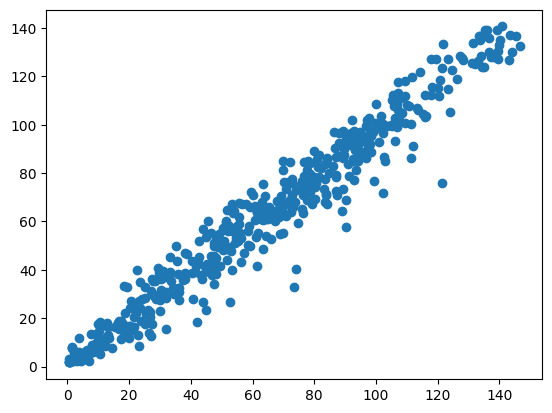

In [79]:
plt.scatter(y_train,y_pred)

In [80]:

y_pred = reg_grid.predict(X_test)
print("R2", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RSME:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred))

R2 0.8657006256977237
MAE: 10.07630358941833
RSME: 14.17595716602996
MAPE: 0.2758552956076725


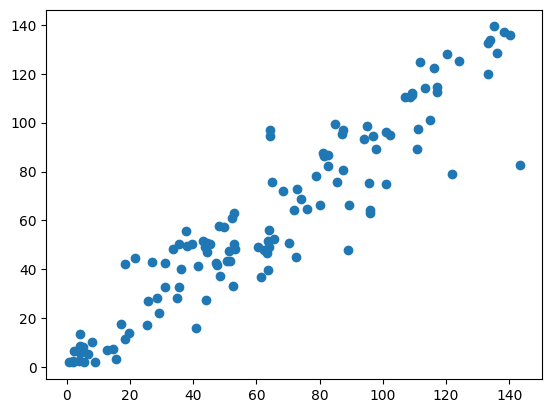

In [81]:
plt.scatter(y_test,y_pred)

In [82]:
X_train

,Fossil Gas,Hydro Pumped Storage.1,Nuclear,Waste,Fossil Oil,Fossil Hard coal
23,6470.750000,1118.416667,7060.791667,192.083333,79.416667,461.125000
582,5924.625000,1078.208333,6879.583333,208.875000,32.625000,0.000000
287,4160.083333,1132.916667,6069.250000,181.791667,20.500000,300.041667
322,6666.083333,660.833333,5087.583333,206.791667,14.333333,268.708333
132,3105.833333,1482.416667,5041.875000,234.208333,43.500000,315.541667
...,...,...,...,...,...,...
71,3752.958333,1505.416667,3655.625000,207.208333,34.958333,247.083333
106,3012.916667,541.000000,5282.541667,137.208333,35.875000,342.208333
270,2751.375000,1456.208333,6957.041667,158.666667,10.625000,565.375000
435,5241.416667,539.208333,7121.458333,175.583333,20.541667,192.000000


In [84]:
X_train[features_hard_voting].describe()

,Fossil Gas,Hydro Pumped Storage.1,Nuclear,Waste,Fossil Oil,Fossil Hard coal
count,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000
mean,5065.598696,1055.143086,5981.146415,195.931354,31.456714,287.442264
std,2068.122492,505.778173,1253.636360,41.440326,17.442003,143.724365
min,2067.166667,36.041667,11.750000,96.375000,2.833333,0.000000
25%,3621.666667,652.958333,5092.739583,170.093750,19.135417,204.552083
50%,4578.770833,1065.937500,6409.437500,193.250000,27.041667,282.750000
75%,5988.802083,1403.020833,6986.104167,223.489583,42.812500,350.072917
max,15269.583333,2913.208333,7135.916667,309.041667,91.125000,914.541667


In [85]:
y_train.describe()

count    488.000000
mean      63.058748
std       38.718154
min        0.401250
25%       29.858437
50%       62.434583
75%       92.837812
max      146.515000
Name: target, dtype: float64

Las cifras son bastante buenas. Mantendremos el modelo.

In [86]:
model_lgb = reg_grid.best_estimator_
reg_grid.best_estimator_
with open('./models/model_lgb.pkl', 'wb') as f:
    pickle.dump(model_lgb, f)